In [1]:
import pandas as pd

In [2]:
df_2 = pd.read_csv(r'../../data/V_OM_WORK_TASK.csv')

In [3]:
#remove bloat columns
df = df_2[['DESCRIPTION', 'TASK_TYPE', 'TASK_PRIORITY', 'REQUEST_CLASS', 'SERVICE_CLASS', 'BUILDING', 'CUSTOMER_ORGANIZATION', 'CUSTOMER_DIVISION', 'CUSTOMER_DEPARTMENT', 'RESPONSIBLE_ORGANIZATION_NAME']]
df = df.dropna()

In [4]:
import matplotlib.pyplot as plt

#take value counts of each request class to find frequency of each
class_counts = pd.DataFrame(df['REQUEST_CLASS'].value_counts().rename_axis('Class').reset_index(name='Counts'))

# plt.figure(figsize=(10, 8))
# plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%')
# plt.title('Distribution of Building Class (FEP_BUILDING_CLASS)')
# plt.show()


In [5]:
class_counts

,Class,Counts
0,Interior Lights Not Working,6476
1,Too Hot,3650
2,Toilet/Urinal,2698
3,Other Plumbing Issues,2285
4,Too Cold,2170
...,...,...
379,Residential Laundry Equipment,1
380,Moving Services,1
381,"Cardreader, No Power (Billable)",1
382,"Key Pad, Program Code (Billable)",1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import warnings
import matplotlib.pyplot as plt

def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

accuracies = []
macro_precisions = []
macro_recalls = []
weighted_precisions = []
weighted_recalls = []

#change threshold for min number of tickets 
count_lst = [1, 5, 10, 50, 100, 500, 1000, 2000]

for i in count_lst:
    
    #take only requests class with atleast i occurances
    mod_counts =  class_counts[class_counts['Counts'] >= i]
    filter_df = df[df['REQUEST_CLASS'].isin(mod_counts['Class'])]

    #encode columns for random forest
    le = LabelEncoder()
    for col in filter_df.columns:
        filter_df[col] = le.fit_transform(filter_df[col].astype(str))

    X = filter_df[['TASK_TYPE', 'TASK_PRIORITY', 'SERVICE_CLASS', 'BUILDING', 'CUSTOMER_ORGANIZATION', 'CUSTOMER_DIVISION', 'CUSTOMER_DEPARTMENT', 'RESPONSIBLE_ORGANIZATION_NAME']]
    y = filter_df['REQUEST_CLASS']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestClassifier()

    #train
    model.fit(X_train, y_train)

    #predict
    predictions = model.predict(X_test)
    
    #compare
    results = classification_report(y_test, predictions, output_dict=True)

    accuracies.append(results['accuracy'])
    macro_precisions.append(results['macro avg']['precision'])
    macro_recalls.append(results['macro avg']['recall'])
    weighted_precisions.append(results['weighted avg']['precision'])
    weighted_recalls.append(results['weighted avg']['recall'])

    print(f'Classification report for {i}')
    print(f'Overall accuracy {results['accuracy']}')
    print(f'Macro percision {results['macro avg']['precision']}')
    print(f'Macro recall {results['macro avg']['recall']}')
    print(f'Weighted percision {results['weighted avg']['precision']}')
    print(f'Weighted recall {results['weighted avg']['recall']}')
    print('========================================')

Classification report for 1
Overall accuracy 0.5787837977830727
Macro percision 0.36094967328419164
Macro recall 0.32425161834310606
Weighted percision 0.561975528463922
Weighted recall 0.5787837977830727
Classification report for 5
Overall accuracy 0.5761016070502851
Macro percision 0.3589470551550127
Macro recall 0.32590711821915525
Weighted percision 0.5588687657539215
Weighted recall 0.5761016070502851
Classification report for 10
Overall accuracy 0.5828829765121596
Macro percision 0.3942083871124308
Macro recall 0.3647086640524544
Weighted percision 0.5669921852885671
Weighted recall 0.5828829765121596
Classification report for 50
Overall accuracy 0.591006538750134
Macro percision 0.4637061715650671
Macro recall 0.43824242962754456
Weighted percision 0.5759540319340282
Weighted recall 0.591006538750134
Classification report for 100
Overall accuracy 0.6142841238031619
Macro percision 0.526534449517239
Macro recall 0.49749805427426336
Weighted percision 0.6000407341970487
Weighted r

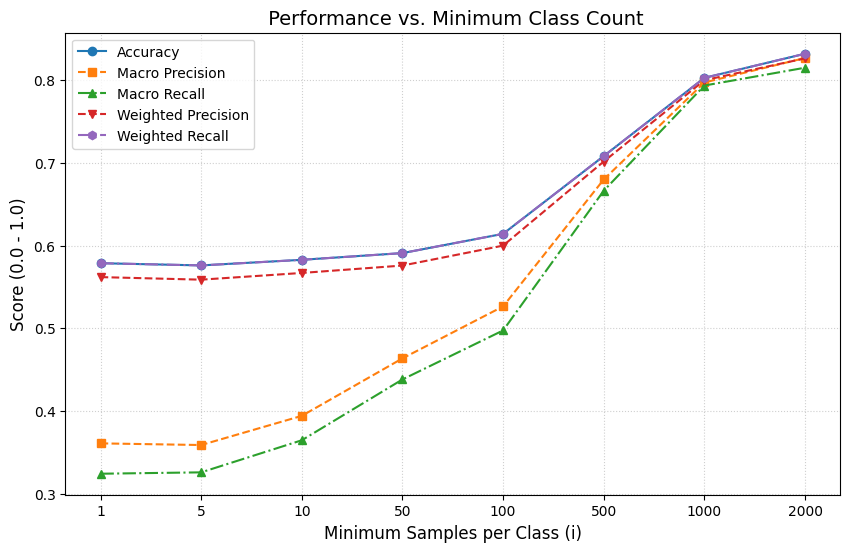

In [11]:
plt.figure(figsize=(10, 6))

x_indices = range(len(count_lst))

plt.plot(x_indices, accuracies, marker='o', label='Accuracy', linestyle='-')
plt.plot(x_indices, macro_precisions, marker='s', label='Macro Precision', linestyle='--')
plt.plot(x_indices, macro_recalls, marker='^', label='Macro Recall', linestyle='-.')
plt.plot(x_indices, weighted_precisions, marker='v', label='Weighted Precision', linestyle='--')
plt.plot(x_indices, weighted_recalls, marker='h', label='Weighted Recall', linestyle='-.')

plt.xticks(ticks=x_indices, labels=count_lst)

plt.title(' Performance vs. Minimum Class Count', fontsize=14)
plt.xlabel('Minimum Samples per Class (i)', fontsize=12)
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [ ]:
df_filter = df.groupby(['REQUEST_CLASS']).size().reset_index(name='COUNT')
df_filter.to_csv('REQ_COUNTS.csv')